In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from netCDF4 import Dataset
import os

In [6]:
print(os.getcwd())

/User/homes/ppapastefanou


In [2]:
rtp = '/Users/pp/data/Simulations/PHS_GFO'

In [4]:
df = pd.read_csv(f"{rtp}/SwissParameterListWide_24_1000000.csv")

In [7]:
ds = Dataset(f"{rtp}/Sens_Output_Agg.nc")
x = ds['RMSE_swiss_trees'][:]
df_res = pd.DataFrame(x)
df_c = pd.concat([df, df_res], axis = 1)

In [9]:
#os.mkdir(f"{rtp}/post")
for i in range(0, 14):
    df_i = df_c.sort_values(by = [i]).head(10000).copy()
    df_i.to_csv(f"{rtp}/Best_{i}.csv")
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13


In [10]:
range_alive = [1, 4, 9, 10, 11, 12, 13]
range_dead = [0, 3, 6, 7]

In [12]:
for i in range_dead:
    df_i = df_c.sort_values(by = [i]).head(10000).copy()
    df_i.to_csv(f"{rtp}/Best_dead_{i}.csv")
    print(i)

0
3
6
7


In [13]:
df_c['mean_alive'] = np.mean(df_c[range_alive].values, axis = 1)

In [15]:
df_i = df_c.sort_values(by = ['mean_alive']).head(10000).copy()
df_i.to_csv(f"{rtp}/Best_Alive_avg.csv")

In [16]:
pwd

'/Users/pp/Documents/Repos/plant_hydro_standalone/py/analysis'

(array([   9.,  425.,  598.,  362.,  307.,  271.,  327.,  408.,  641.,
        6652.]),
 array([1.07477927, 1.27051878, 1.46625841, 1.66199791, 1.85773754,
        2.05347705, 2.24921656, 2.44495606, 2.64069581, 2.83643532,
        3.03217483]),
 <BarContainer object of 10 artists>)

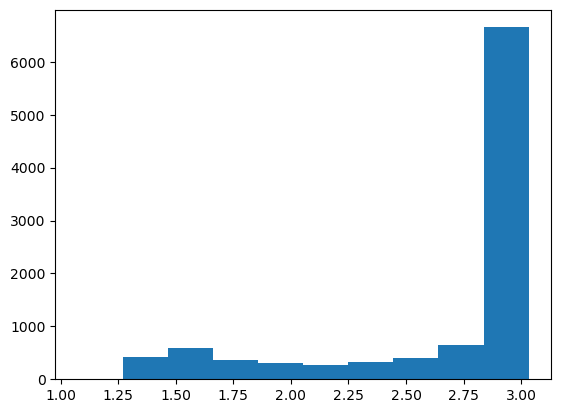

In [17]:
plt.hist(df_i[0], bins = 10)

In [18]:
df_i['k_xylem_sat'].describe()

count    10000.000000
mean        37.601276
std         48.336111
min          1.000036
25%          3.791937
50%         14.597412
75%         54.094872
max        199.915520
Name: k_xylem_sat, dtype: float64

(array([1285., 1259., 1226., 1289., 1207., 1259., 1235., 1240.]),
 array([0.80002125, 0.8200173 , 0.84001335, 0.8600094 , 0.88000545,
        0.9000015 , 0.91999755, 0.9399936 , 0.95998965]),
 <BarContainer object of 8 artists>)

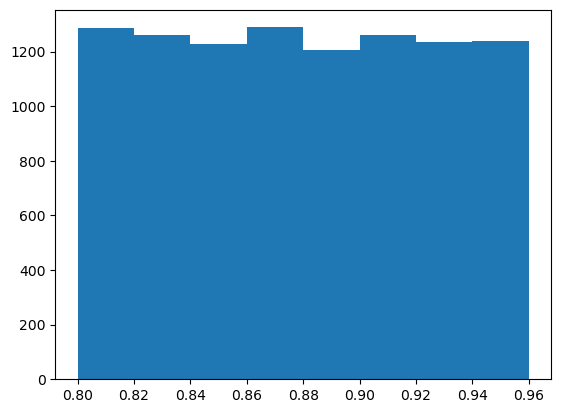

In [19]:
plt.hist(df_i['jackson_root_beta'], bins = 8)

FileExistsError: [Errno 17] File exists: '/Net/Groups/BSI/work_scratch/ppapastefanou/simulations/plant_hydraulics_standalone/2024/swiss/rough_lower_k_low_layer/post'

In [234]:
df_i['k_soil_top'] = df_i['k_soil_sats'].str.split(';').str[0].astype(float)

(array([ 983.,  955., 1005., 1053.,  996.,  985., 1020., 1036.,  972.,
         995.]),
 array([-17.99978667, -17.19983807, -16.39988946, -15.59994085,
        -14.79999225, -14.00004364, -13.20009503, -12.40014643,
        -11.60019782, -10.80024921, -10.00030061]),
 <BarContainer object of 10 artists>)

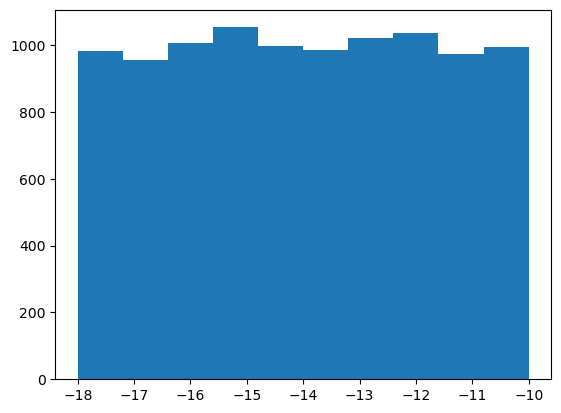

In [235]:
plt.hist(np.log10(df_i['k_soil_top']), bins = 10)

In [187]:
df_i['clay_frac_top'] = df_i['clay_fracs'].str.split(';').str[0].astype(float)

(array([1073., 1035., 1045., 1015., 1011.,  963.,  938.,  981.,  960.,
         979.]),
 array([0.55003073, 0.56302536, 0.57602   , 0.58901463, 0.60200926,
        0.6150039 , 0.62799853, 0.64099316, 0.65398779, 0.66698243,
        0.67997706]),
 <BarContainer object of 10 artists>)

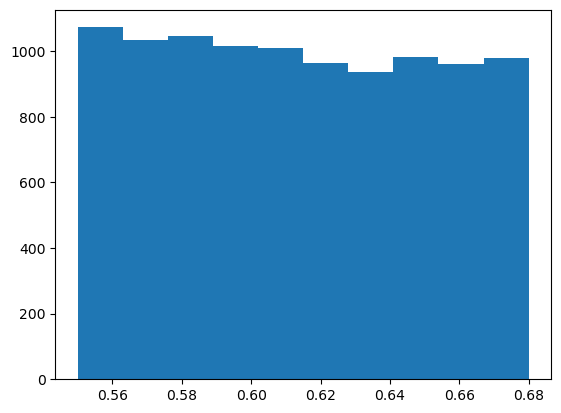

In [188]:
plt.hist(df_i['clay_frac_top'], bins = 10)

(array([ 461.,  647.,  450.,  367.,  385.,  439.,  630., 6621.]),
 array([1.55343509, 1.72558737, 1.89773965, 2.06989193, 2.24204397,
        2.41419625, 2.58634853, 2.75850081, 2.9306531 ]),
 <BarContainer object of 8 artists>)

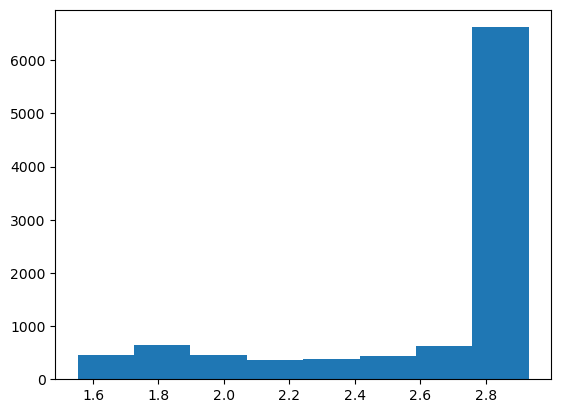

In [20]:
plt.hist(df_i[6], bins = 8)

(array([4484., 1270.,  725.,  515.,  382.,  340.,  280.,  259.,  218.,
         219.,  201.,  173.,  149.,  144.,  114.,  128.,  113.,   96.,
         103.,   87.]),
 array([  1.00003623,  10.9458104 ,  20.89158456,  30.83735873,
         40.7831329 ,  50.72890706,  60.67468123,  70.6204554 ,
         80.56622956,  90.51200373, 100.45777789, 110.40355206,
        120.34932623, 130.29510039, 140.24087456, 150.18664872,
        160.13242289, 170.07819706, 180.02397122, 189.96974539,
        199.91551955]),
 <BarContainer object of 20 artists>)

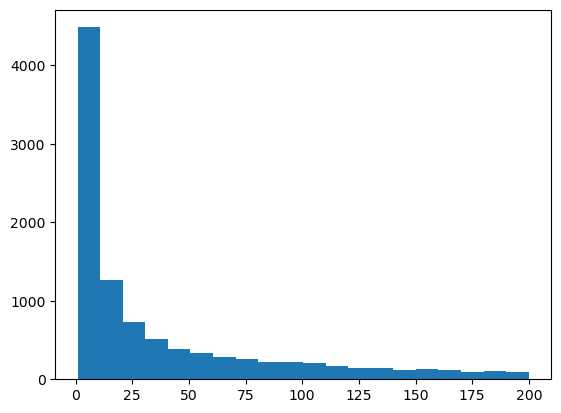

In [21]:
plt.hist(df_i['k_xylem_sat'], bins = 20)

(array([483., 492., 511., 496., 466., 497., 481., 484., 503., 523., 480.,
        513., 505., 533., 495., 514., 521., 483., 497., 523.]),
 array([6.58682150e-01, 5.06233091e+01, 1.00587936e+02, 1.50552563e+02,
        2.00517190e+02, 2.50481817e+02, 3.00446444e+02, 3.50411071e+02,
        4.00375698e+02, 4.50340325e+02, 5.00304952e+02, 5.50269579e+02,
        6.00234206e+02, 6.50198833e+02, 7.00163460e+02, 7.50128086e+02,
        8.00092713e+02, 8.50057340e+02, 9.00021967e+02, 9.49986594e+02,
        9.99951221e+02]),
 <BarContainer object of 20 artists>)

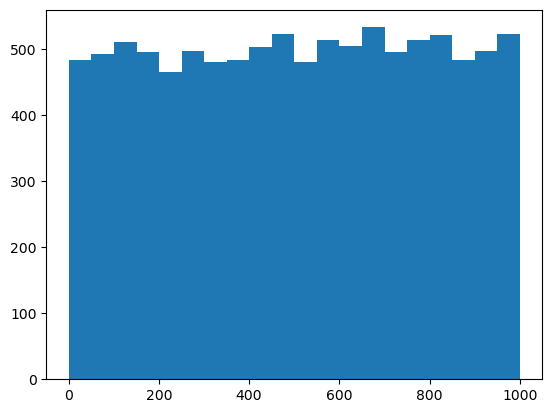

In [22]:
plt.hist(df_i['stem_hydraulic_capacitance'], bins = 20)

(array([1213.,    0., 1250.,    0.,    0., 1260.,    0.,    0., 1264.,
           0.,    0., 1228.,    0.,    0., 1287.,    0.,    0., 1202.,
           0., 1296.]),
 array([0.  , 0.35, 0.7 , 1.05, 1.4 , 1.75, 2.1 , 2.45, 2.8 , 3.15, 3.5 ,
        3.85, 4.2 , 4.55, 4.9 , 5.25, 5.6 , 5.95, 6.3 , 6.65, 7.  ]),
 <BarContainer object of 20 artists>)

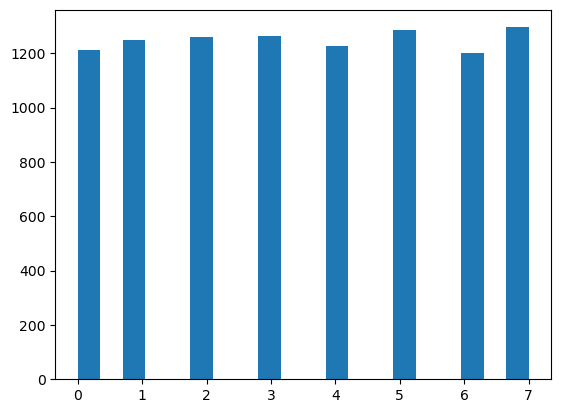

In [23]:
plt.hist(df_i['soil_profile_index'], bins = 20)